# Fraud Detection — Baseline Model

**Purpose:**  
Establish benchmark metrics before building the full production pipeline.  
Every number here becomes the bar that `src/train.py` must beat.

**What we do here:**
1. Minimal preprocessing — just enough to feed a model
2. Train a quick XGBoost baseline
3. Evaluate with the right metrics (Average Precision, not just AUC-ROC)
4. Tune threshold using F2-score
5. Analyse feature importance
6. Document baseline numbers

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix,
    f1_score, fbeta_score
)
import xgboost as xgb

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

DATA_DIR      = '../data/raw'
PROCESSED_DIR = '../data/processed'
SEED          = 42

print('Libraries loaded.')

Libraries loaded.


## 2. Load & Minimal Preprocessing

In [2]:
# Read with optimized dtypes to reduce memory during load
txn = pd.read_csv(
    f'{DATA_DIR}/train_transaction.csv',
    dtype={col: 'float32' for col in 
           [f'V{i}' for i in range(1, 340)] + 
           ['TransactionAmt', 'card1', 'card2', 'card3', 
            'card5', 'addr1', 'addr2', 'dist1', 'dist2']}
)

idn = pd.read_csv(f'{DATA_DIR}/train_identity.csv')

df = txn.merge(idn, on='TransactionID', how='left')

# Free memory immediately
del txn, idn
import gc
gc.collect()

# Sample 20% — stratified to preserve fraud ratio
df = df.groupby('isFraud', group_keys=False).apply(
    lambda x: x.sample(frac=0.2, random_state=42)
).reset_index(drop=True)

# Downcast remaining float64s
float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].astype('float32')

print(f'Shape        : {df.shape}')
print(f'Fraud rate   : {df["isFraud"].mean()*100:.2f}%')
print(f'Memory usage : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Shape        : (118108, 434)
Fraud rate   : 3.50%
Memory usage : 349.4 MB


In [3]:
# Minimal preprocessing — just enough for a baseline
# This is intentionally simple — NOT the production pipeline

df_model = df.copy()

# Drop ID and time columns
df_model.drop(columns=['TransactionID', 'TransactionDT'], inplace=True)

# Label encode all object columns
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'Encoding {len(cat_cols)} categorical columns...')
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = df_model[col].fillna('unknown').astype(str)
    df_model[col] = le.fit_transform(df_model[col])

# Fill remaining nulls with -1
df_model.fillna(-1, inplace=True)

print(f'Nulls remaining : {df_model.isnull().sum().sum()}')
print(f'Features        : {df_model.shape[1] - 1}')

Encoding 31 categorical columns...
Nulls remaining : 0
Features        : 431


In [4]:
# Stratified split — preserve fraud ratio
X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
spw = round(neg / pos, 2)

print(f'Train : {X_train.shape[0]:,} rows | fraud: {y_train.mean()*100:.2f}%')
print(f'Val   : {X_val.shape[0]:,} rows | fraud: {y_val.mean()*100:.2f}%')
print(f'scale_pos_weight = {spw}')

Train : 94,486 rows | fraud: 3.50%
Val   : 23,622 rows | fraud: 3.50%
scale_pos_weight = 27.58


## 3. Train Baseline XGBoost

In [5]:
# Baseline params — intentionally simple
# Production train.py will use more regularisation and tuning
baseline_params = {
    'n_estimators':          300,
    'max_depth':             6,
    'learning_rate':         0.1,
    'subsample':             0.8,
    'colsample_bytree':      0.8,
    'scale_pos_weight':      spw,
    'eval_metric':           'aucpr',
    'early_stopping_rounds': 30,
    'random_state':          SEED,
    'n_jobs':                -1,
    'verbosity':             0,
}

print('Training baseline model...')
start = time.time()

model = xgb.XGBClassifier(**baseline_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=50,
)

elapsed = round(time.time() - start, 1)
print(f'\nTraining complete in {elapsed}s')
print(f'Best iteration : {model.best_iteration}')

Training baseline model...
[0]	validation_0-aucpr:0.30345
[50]	validation_0-aucpr:0.52351
[100]	validation_0-aucpr:0.57101
[150]	validation_0-aucpr:0.58989
[200]	validation_0-aucpr:0.60381
[250]	validation_0-aucpr:0.61893
[299]	validation_0-aucpr:0.62559

Training complete in 63.8s
Best iteration : 299


## 4. Evaluate — Why AUC-ROC Alone is Misleading

In [6]:
val_proba = model.predict_proba(X_val)[:, 1]

auc_roc = roc_auc_score(y_val, val_proba)
avg_prec = average_precision_score(y_val, val_proba)
baseline_ap = y_val.mean()   # random classifier baseline

print('='*50)
print('  BASELINE MODEL METRICS')
print('='*50)
print(f'  AUC-ROC          : {auc_roc:.4f}')
print(f'  Avg Precision    : {avg_prec:.4f}  ← primary metric')
print(f'  Random baseline  : {baseline_ap:.4f}  (always predict fraud)')
print(f'  AP lift over random: {avg_prec/baseline_ap:.1f}x')
print('='*50)
print()
print('NOTE: AUC-ROC looks high (~0.92) because 96.5% of')
print('transactions are legit — easy to get right.')
print('Average Precision is the honest metric for imbalanced data.')

  BASELINE MODEL METRICS
  AUC-ROC          : 0.9182
  Avg Precision    : 0.6257  ← primary metric
  Random baseline  : 0.0350  (always predict fraud)
  AP lift over random: 17.9x

NOTE: AUC-ROC looks high (~0.92) because 96.5% of
transactions are legit — easy to get right.
Average Precision is the honest metric for imbalanced data.


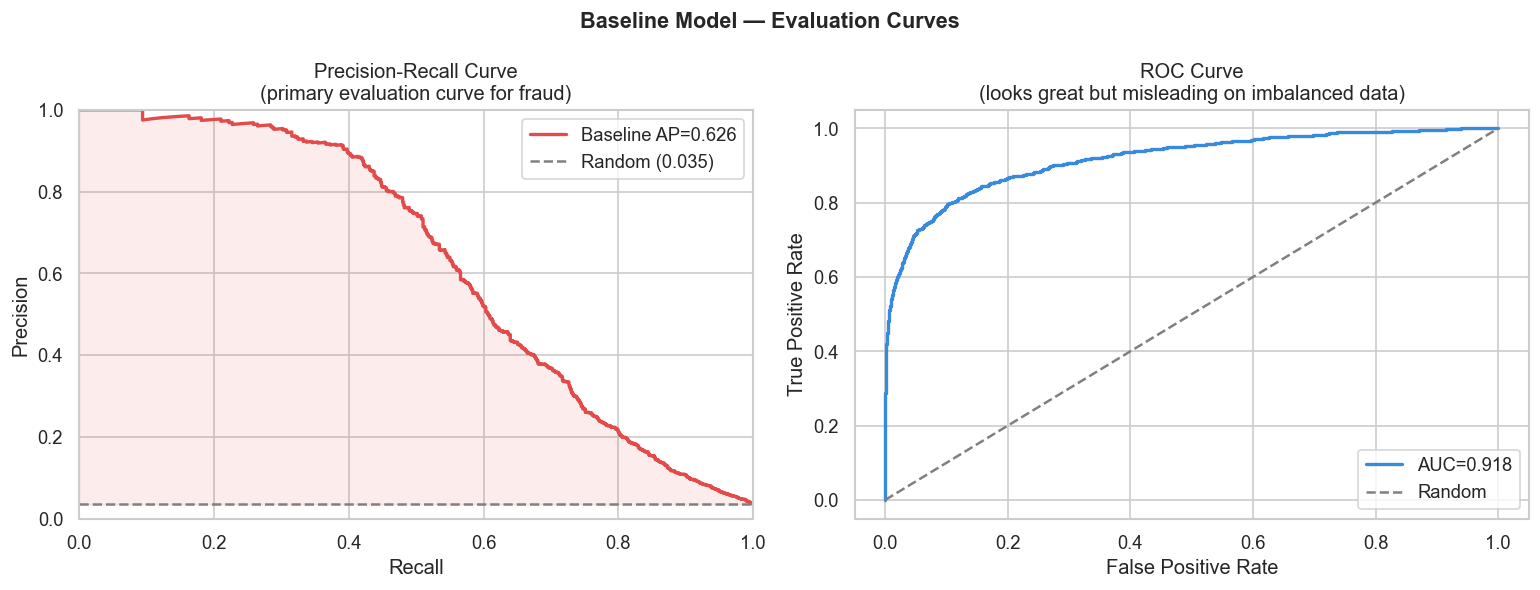

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_val, val_proba)
axes[0].plot(rec, prec, color='#E24B4A', lw=2, label=f'Baseline AP={avg_prec:.3f}')
axes[0].axhline(y=y_val.mean(), color='gray', linestyle='--',
                label=f'Random ({y_val.mean():.3f})')
axes[0].fill_between(rec, prec, y_val.mean(), alpha=0.1, color='#E24B4A')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve\n(primary evaluation curve for fraud)')
axes[0].legend()
axes[0].set_xlim([0,1])
axes[0].set_ylim([0,1])

# ROC curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[1].plot(fpr, tpr, color='#378ADD', lw=2, label=f'AUC={auc_roc:.3f}')
axes[1].plot([0,1],[0,1], 'gray', linestyle='--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\n(looks great but misleading on imbalanced data)')
axes[1].legend()

plt.suptitle('Baseline Model — Evaluation Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_08_baseline_eval_curves.png', bbox_inches='tight')
plt.show()

## 5. Threshold Tuning — Why 0.5 is Wrong

In [8]:
# Default threshold = 0.5
y_pred_default = (val_proba >= 0.5).astype(int)
f1_default     = f1_score(y_val, y_pred_default, zero_division=0)
f2_default     = fbeta_score(y_val, y_pred_default, beta=2, zero_division=0)
report_default = classification_report(y_val, y_pred_default, output_dict=True, zero_division=0)

print('At default threshold = 0.5:')
print(f'  Precision (fraud) : {report_default["1"]["precision"]:.4f}')
print(f'  Recall (fraud)    : {report_default["1"]["recall"]:.4f}')
print(f'  F1 (fraud)        : {f1_default:.4f}')
print(f'  F2 (fraud)        : {f2_default:.4f}')

At default threshold = 0.5:
  Precision (fraud) : 0.3631
  Recall (fraud)    : 0.7025
  F1 (fraud)        : 0.4788
  F2 (fraud)        : 0.5919


In [9]:
# Find optimal threshold using F2 score (beta=2 = recall weighted)
# beta=2 means we care 2x more about recall than precision
# In fraud: missing fraud (FN) is worse than a false alarm (FP)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

beta  = 2.0
beta2 = beta ** 2
f2_scores = (1 + beta2) * precisions * recalls / (beta2 * precisions + recalls + 1e-8)

best_idx = int(np.argmax(f2_scores))
best_thr = float(thresholds[best_idx]) if best_idx < len(thresholds) else 0.5

y_pred_tuned = (val_proba >= best_thr).astype(int)
report_tuned = classification_report(y_val, y_pred_tuned, output_dict=True, zero_division=0)
f2_tuned     = fbeta_score(y_val, y_pred_tuned, beta=2, zero_division=0)

print(f'Optimal threshold (F2) = {best_thr:.4f}')
print(f'  Precision (fraud) : {report_tuned["1"]["precision"]:.4f}')
print(f'  Recall (fraud)    : {report_tuned["1"]["recall"]:.4f}')
print(f'  F1 (fraud)        : {f1_score(y_val, y_pred_tuned, zero_division=0):.4f}')
print(f'  F2 (fraud)        : {f2_tuned:.4f}')

cm = confusion_matrix(y_val, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()
print(f'\nConfusion matrix at optimal threshold:')
print(f'  TP={tp:,}  FN={fn:,}  → caught {tp/(tp+fn)*100:.1f}% of fraud')
print(f'  FP={fp:,}  TN={tn:,}  → false alarm rate {fp/(fp+tn)*100:.2f}%')

Optimal threshold (F2) = 0.5401
  Precision (fraud) : 0.4014
  Recall (fraud)    : 0.6747
  F1 (fraud)        : 0.5034
  F2 (fraud)        : 0.5939

Confusion matrix at optimal threshold:
  TP=558  FN=269  → caught 67.5% of fraud
  FP=832  TN=21,963  → false alarm rate 3.65%


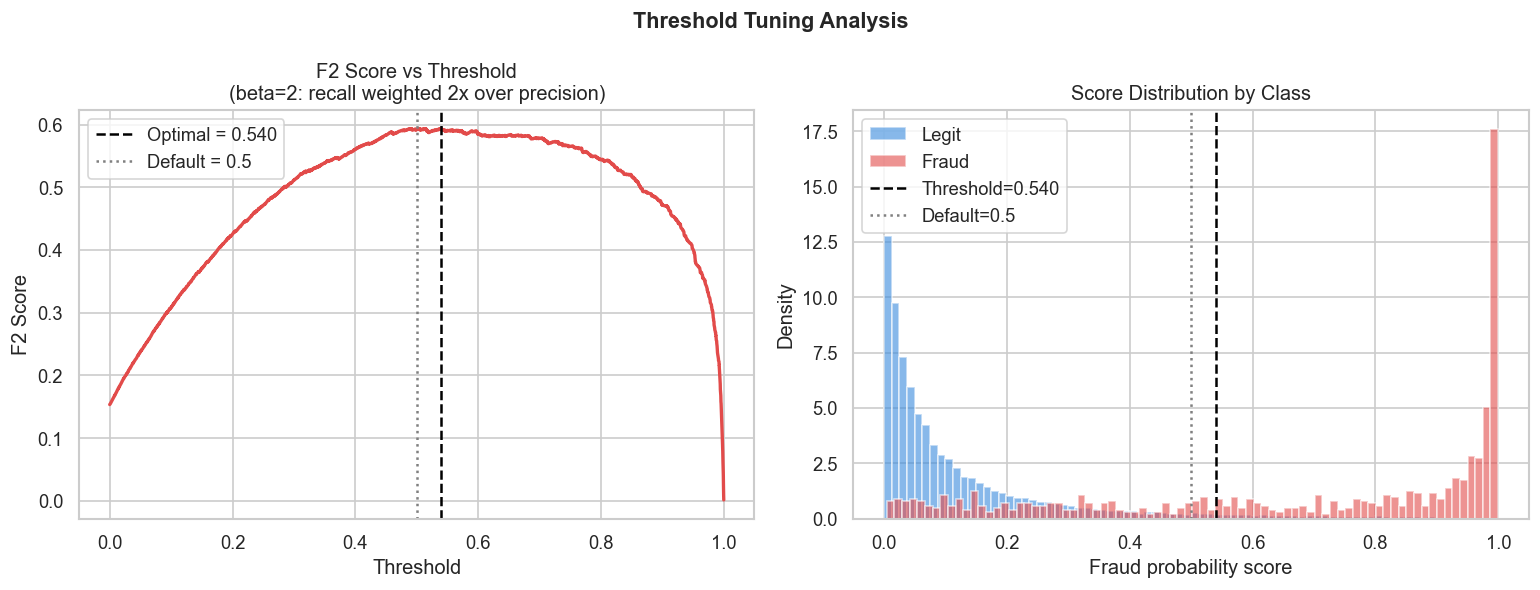

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# F2 score across thresholds
axes[0].plot(thresholds, f2_scores[:-1], color='#E24B4A', lw=2)
axes[0].axvline(x=best_thr, color='black', linestyle='--',
                label=f'Optimal = {best_thr:.3f}')
axes[0].axvline(x=0.5, color='gray', linestyle=':',
                label='Default = 0.5')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F2 Score')
axes[0].set_title('F2 Score vs Threshold\n(beta=2: recall weighted 2x over precision)')
axes[0].legend()

# Score distribution by class
axes[1].hist(val_proba[y_val==0], bins=80, alpha=0.6,
             color='#378ADD', density=True, label='Legit')
axes[1].hist(val_proba[y_val==1], bins=80, alpha=0.6,
             color='#E24B4A', density=True, label='Fraud')
axes[1].axvline(x=best_thr, color='black', linestyle='--',
                label=f'Threshold={best_thr:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle=':',
                label='Default=0.5')
axes[1].set_xlabel('Fraud probability score')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution by Class')
axes[1].legend()

plt.suptitle('Threshold Tuning Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_09_threshold_tuning.png', bbox_inches='tight')
plt.show()

## 6. Feature Importance

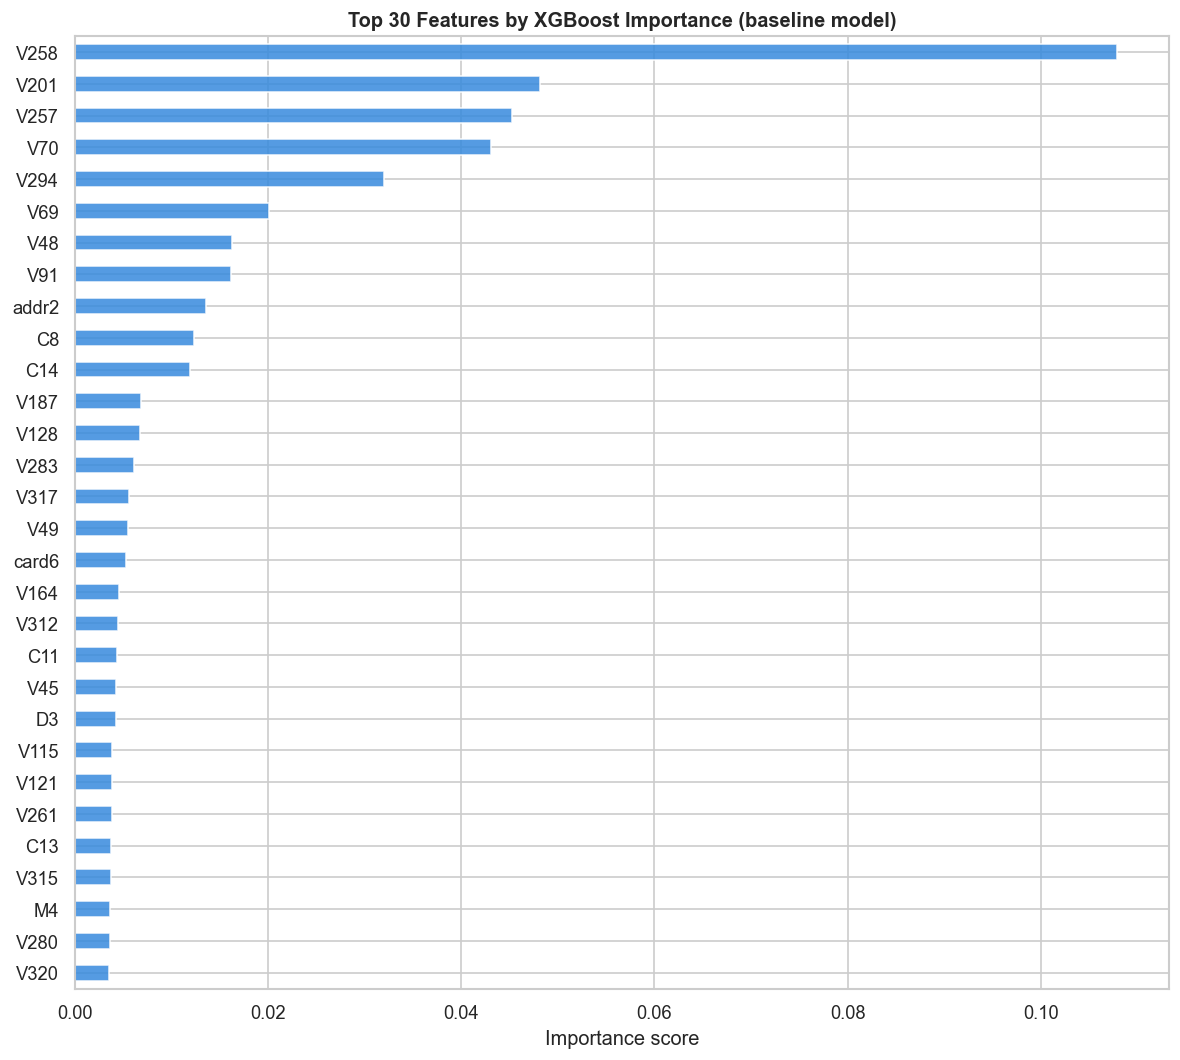

Top 10 features:
V258     0.107868
V201     0.048105
V257     0.045264
V70      0.043090
V294     0.032020
V69      0.020104
V48      0.016297
V91      0.016117
addr2    0.013602
C8       0.012310


In [11]:
fi = pd.Series(model.feature_importances_, index=X_train.columns)
fi_top30 = fi.sort_values(ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 9))
fi_top30[::-1].plot(kind='barh', ax=ax, color='#378ADD', alpha=0.85)
ax.set_title('Top 30 Features by XGBoost Importance (baseline model)',
             fontweight='bold')
ax.set_xlabel('Importance score')
plt.tight_layout()
plt.savefig(f'{PROCESSED_DIR}/fig_10_feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 10 features:')
print(fi_top30.head(10).to_string())

In [12]:
# Which column groups dominate importance?
fi_df = fi.reset_index()
fi_df.columns = ['feature', 'importance']
fi_df['group'] = fi_df['feature'].map(lambda c:
    'V-col'     if c.startswith('V') else
    'id_col'    if c.startswith('id_') else
    'M-flag'    if c.startswith('M') else
    'card/addr' if c.startswith(('card','addr')) else
    'other'
)

group_importance = fi_df.groupby('group')['importance'].sum().sort_values(ascending=False)
print('Importance by column group:')
print(group_importance.to_string())

Importance by column group:
group
V-col        0.787804
other        0.106829
id_col       0.049208
card/addr    0.032127
M-flag       0.024031


## 7. Baseline Numbers — The Bar to Beat

In [13]:
baseline_results = {
    'model':              'XGBoost baseline (minimal preprocessing)',
    'n_estimators':       model.best_iteration,
    'auc_roc':            round(auc_roc, 4),
    'avg_precision':      round(avg_prec, 4),
    'random_ap_baseline': round(float(y_val.mean()), 4),
    'optimal_threshold':  round(best_thr, 4),
    'precision_fraud':    round(report_tuned['1']['precision'], 4),
    'recall_fraud':       round(report_tuned['1']['recall'], 4),
    'f1_fraud':           round(f1_score(y_val, y_pred_tuned, zero_division=0), 4),
    'f2_fraud':           round(f2_tuned, 4),
    'fraud_caught_pct':   round(tp / (tp + fn) * 100, 2),
    'false_alarm_rate':   round(fp / (fp + tn) * 100, 2),
}

print('='*55)
print('  BASELINE RESULTS — TARGET FOR src/train.py TO BEAT')
print('='*55)
for k, v in baseline_results.items():
    print(f'  {k:<25} : {v}')
print('='*55)

# Save results
import json
with open(f'{PROCESSED_DIR}/baseline_results.json', 'w') as f:
    json.dump(baseline_results, f, indent=2)
print(f'\nSaved → {PROCESSED_DIR}/baseline_results.json')

  BASELINE RESULTS — TARGET FOR src/train.py TO BEAT
  model                     : XGBoost baseline (minimal preprocessing)
  n_estimators              : 299
  auc_roc                   : 0.9182
  avg_precision             : 0.6257
  random_ap_baseline        : 0.035
  optimal_threshold         : 0.5401
  precision_fraud           : 0.4014
  recall_fraud              : 0.6747
  f1_fraud                  : 0.5034
  f2_fraud                  : 0.5939
  fraud_caught_pct          : 67.47
  false_alarm_rate          : 3.65

Saved → ../data/processed/baseline_results.json


## 8. What the Production Pipeline Improves

| Baseline (this notebook) | Production `src/train.py` |
|---|---|
| Fill all nulls with -1 | Null strategy by column type (0 for V-cols, -1+flag for id) |
| No frequency encoding | card1/addr1 frequency encoded (leak-free) |
| No time features | hour, is_night, is_weekend engineered |
| No amount features | log1p, decimal, cents, is_round |
| 300 estimators, lr=0.1 | 600 estimators, lr=0.05 + regularisation |
| No MLflow tracking | Full experiment tracking |
| Notebook only | Tested, reusable `preprocess.py` + `train.py` |

**Expected improvement:** +5–15% Average Precision from better preprocessing alone.

---